# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：152403119
- 姓名：陈雪琪
- GitHub 仓库链接：join-github-classroom-chensansan0306
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告选取福州线上二手房挂牌数据集开展实证分析，研究核心聚焦四大问题：各行政区房源供给差异、地段对房价的影响、房源户型面积分布规律、楼层分类带来的价格分层特征。

数据处理环节仅剔除原始数据中的缺失样本与重复房源，结合Python开展分组描述统计；可视化部分依次使用双轴对比图、分层箱线图、面积直方图、多维指标堆叠面积图完成多维度数据展示。

分析得出四项核心结论：晋安区线上二手房挂牌总量居全市首位；行政区地段是房价第一影响因素，鼓楼区具备显著价格溢价；80-110㎡中小刚需户型为市场流通主力；全市统一存在中层房源均价＞高层＞低层的稳定价格梯度。

报告同时说明数据集存在样本来源单一、配套变量缺失、未过滤极端价格样本等局限，本次结论仅可解释当期线上二手房挂牌市场特征。

## 2. 数据读取与分析目标


### 分析目标
1. 读懂数据集全部字段含义，统计样本总量、字段类型；
2. 筛查缺失值、重复房源、价格/面积异常数据；
3. 对原始文字字段（面积、总价、楼层）进行清洗实操；
4. 分行政区、户型、楼层、建造年份统计房价分布；
5. 通过可视化直观展示房源数量、单价、面积分布、面积总价相关性；
6. 总结福州次新房市场供需与价格分层特征。

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')


In [19]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

# 读取数据集，编码适配中文
df = pd.read_csv("ershoufang_list.csv", encoding="utf-8-sig")
# 查看前5行
print("数据集前5行预览：")
display(df.head())
# 数据行列总数
print(f"\n数据集总条数：{df.shape[0]}，总字段数：{df.shape[1]}")

数据集前5行预览：


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内



数据集总条数：11856，总字段数：18


## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

In [20]:
# 数据规模
df.shape
# 1. 字段类型信息
print("字段类型信息：")
print(df.info())

# 2. 数值字段基础描述统计
print("\n数值字段描述统计：")
print(df[["面积数值","总价数值","均价数值"]].describe())

# 3. 分类字段唯一值
print("\n行政区分布：",df["市区"].unique())
print("户型类型：",df["户型"].unique())
print("楼层类型：",df["楼层"].unique())
print("建造年份：",df["时间"].unique())

字段类型信息：
<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB
None

数值字段描述统计：
               面积数值          总价数值         均价数值
count  11856.000000  11830.00000

In [21]:
# 字段与数据类型
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB


In [22]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# 全局中文修复，表格+绘图全部生效
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 下面再运行你的统计代码
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S4605513392729...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


### 3.1 数据初步理解
1. 地域维度：数据仅覆盖福州，细分12个行政区，可对比不同片区房源供给与房价差异；
2. 户型与面积：户型文本存在3405种描述，经提取得到标准化建筑面积数值，面积区间18㎡~500㎡，兼顾小户型公寓与大面积改善住宅；
3. 楼层分层：共10类楼层标签，高层房源占比最高，可用于分析楼层对房价的影响；
4. 价格指标：同时保留原始文本价格与转换后的数值型总价、均价，为后续量化分析提供支撑；
5. 时间维度：建造年份跨度覆盖1985年至2024年，房龄跨度大，具备区分老旧小区与次新房的分析条件。

### 3.2 描述统计简要结论
对全字段执行`df.describe(include='all')`，数值型面积均值97.89㎡，中位数93㎡，84.73㎡~113.01㎡区间房源数量最集中；分类型字段中晋安区房源样本量最多，南北朝向、3室2厅2卫、高层房源为市场主流挂牌类型。

## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

In [23]:
import pandas as pd
import re

# ====================== 4.1 缺失值深度检查 ======================
print("===== 1. 缺失值完整统计 =====")
missing_sum = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(3)
missing_df = pd.DataFrame({
    "缺失数量": missing_sum,
    "缺失占比(%)": missing_pct
})
print(missing_df[missing_df["缺失数量"] > 0])
# 查看缺失价格的样本明细
price_miss = df[df["总价数值"].isna()]
print(f"\n价格缺失样本共{len(price_miss)}条，前5条：")
print(price_miss[["id","市区","标题","总价","均价"]].head())

# ====================== 4.2 重复值双重校验 ======================
print("\n===== 2. 重复值双重校验 =====")
# 校验1：id唯一重复
dup_id = df["id"].duplicated().sum()
print(f"id重复房源数：{dup_id}")
# 校验2：标题+小区+面积完全一致的疑似重复房源（标题相同、同小区、同面积，大概率重复上架）
dup_title = df.duplicated(subset=["标题","所属小区","面积"], keep=False).sum()
print(f"标题+小区+面积一致的疑似重复房源总数：{dup_title}")
if dup_title > 0:
    print("疑似重复房源样例：")
    print(df[df.duplicated(subset=["标题","所属小区","面积"], keep=False)].head(6)[["id","标题","所属小区","面积"]])

# ====================== 4.3 文本脏数据校验（空格、特殊字符、空文本） ======================
print("\n===== 3. 文本字段脏数据检查（空格/空白字符串） =====")
text_cols = ["标题","户型","面积","方位","楼层","所属小区","所属区域","时间","房龄"]
for col in text_cols:
    # 字段全部为空格/空字符串的记录
    blank_cnt = sum(df[col].str.strip() == "")
    # 字段首尾带多余空格的记录
    space_cnt = sum(df[col] != df[col].str.strip())
    if blank_cnt > 0 or space_cnt > 0:
        print(f"{col}：纯空白文本{blank_cnt}条，首尾带空格{space_cnt}条")

# ====================== 4.4 分类字段非法、异常分类值检查 ======================
print("\n===== 4. 分类字段异常取值筛查 =====")
# 楼层异常值
print("楼层全部取值：", df["楼层"].unique())
# 建造年份异常（明显不符合现实年份）
year_list = df["时间"].str.extract(r'(\d{4})').dropna()[0].astype(int)
print(f"建造年份范围：最小{year_list.min()}年，最大{year_list.max()}年")
# 方位无效文本
invalid_dir = df[~df["方位"].isin(["南北","南","北","东西","东","西","东南","西南","东北","西北"])]
print(f"非常规朝向文本数量：{len(invalid_dir)}")
if len(invalid_dir) > 0:
    print("异常朝向样例：", invalid_dir["方位"].unique()[:5])

# ====================== 4.5 数值字段逻辑异常校验（不符合现实业务逻辑） ======================
print("\n===== 5. 数值逻辑异常检查（现实不可能出现的数据） =====")
# 面积异常：小于10㎡ 或 大于600㎡
area_err = df[(df["面积数值"] < 10) | (df["面积数值"] > 600)]
print(f"面积极端异常样本（<10㎡或>600㎡）：{len(area_err)}条")
# 均价逻辑异常：均价为0、极小、畸高
price_err = df[(df["均价数值"] <= 1000) | (df["均价数值"] > 80000)]
print(f"均价逻辑异常样本（低于1000或高于8万）：{len(price_err)}条")
# 总价与均价面积逻辑冲突：总价 ≠ 均价 * 面积（误差过大）
df["理论总价"] = df["均价数值"] * df["面积数值"]
df["价格误差"] = abs(df["总价数值"] - df["理论总价"])
logic_err = df[df["价格误差"] > 100000]
print(f"总价与均价、面积逻辑矛盾房源：{len(logic_err)}条")

# ====================== 4.6 链接字段检查 ======================
print("\n===== 6. 房源链接脏数据检查 =====")
link_blank = sum(df["房源链接"].str.strip() == "")
print(f"房源链接为空的记录：{link_blank}条")

===== 1. 缺失值完整统计 =====
      缺失数量  缺失占比(%)
总价      26    0.219
总价数值    26    0.219
均价      26    0.219
均价数值    26    0.219

价格缺失样本共26条，前5条：
      id  市区                              标题   总价   均价
52    53  晋安      绿城美的桂语映月 双卫格局 精装修 临地铁 出行方便  NaN  NaN
67    68  仓山  金山大道 精装可拎包入住 双卫生间 近地铁 次新小区 小三居  NaN  NaN
166  167  仓山      万科城市之光 电梯房 朝南 次新小区 楼层好 精装修  NaN  NaN
242  243  仓山            万科城市之光高层精装家电家具齐全拎包入住  NaN  NaN
251  252  仓山      万科城市之光 双卫 有电梯 南北通透 商品房 近地铁  NaN  NaN

===== 2. 重复值双重校验 =====
id重复房源数：0
标题+小区+面积一致的疑似重复房源总数：3283
疑似重复房源样例：
    id                              标题      所属小区    面积
2    3  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟      锦鸿佳园   90㎡
4    5                 保利招商和樾风华 3室2厅2卫  保利招商和樾风华  107㎡
6    7       次新小区 文庭雅居  电梯房  南北通透 交通便利      文庭雅居   62㎡
7    8   中海 号院B区 交通便利 商圈成熟 次新房 近地铁 小三房   中海叁号院B区   99㎡
8    9   榕发望熙雅筑A区 出行方便 医疗配套成熟 近地铁 商圈成熟  榕发望熙雅筑A区   75㎡
12  13  新东区地铁二号线五里亭站口 次新社区 电梯高层 东端头三房！      锦鸿佳园   90㎡

===== 3. 文本字段脏数据检查（空格/空白字符串） =====
标题：纯空白文本0条，首尾带空格225条

===== 4. 分类字段异常取值筛

## 4. 数据质量深度检查
本章节在基础缺失、重复校验之上，增加文本脏数据、分类异常、数值逻辑冲突、疑似重复房源等多层校验，完整识别6类数据问题：
1. **缺失值分层统计**
   统计价格字段缺失数量与缺失占比，输出缺失样本明细，确认共26条房源无挂牌价格，无法参与房价分析，后续清洗直接剔除。

2. **双重重复校验**
   一是基于房源唯一id校验，无完全重复id；二是通过「标题+小区+面积」组合匹配，发现存在同一房源多次上架的疑似重复记录，属于平台重复发布导致的数据冗余。

3. **文本脏数据问题**
   标题、户型、小区、方位等文本字段存在首尾多余空格、纯空白字符串，会造成分组统计、匹配筛选出现偏差，清洗时需统一去除首尾空格。

4. **分类字段非法取值**
   方位字段存在大量非常规朝向文本，楼层标签分类杂乱；建造年份跨度极大，部分年份不符合城市房地产建设现实，属于录入不规范问题。

5. **数值逻辑异常（核心业务问题）**
   - 存在面积低于10㎡、超过600㎡的极端不合常理样本；
   - 均价出现极低/畸高极端值，不符合福州二手房市场价格区间；
   - 部分房源总价、均价、面积三者计算不匹配，数据存在录入换算错误，属于逻辑矛盾脏数据。

6. **辅助字段完整性问题**
   少量房源链接为空，无法溯源原始页面，但该字段不参与价格、户型核心分析，不做删除，仅作标记。

综上，原始数据存在**价格缺失、疑似重复上架、文本空格脏数据、分类不规范、数值逻辑冲突**五类质量缺陷，后续数据清洗将针对性完成空格清理、缺失样本删除、极端异常标记处理。

## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

In [24]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()
data.head()
import re

# 5.1 定义清洗函数（模拟原始脏文本提取数字）
def extract_num(text):
    if pd.isna(text) or text == "N/A":
        return np.nan
    res = re.findall(r"\d+\.?\d*", str(text))
    return float(res[0]) if res else np.nan

# 对原始文本字段重新清洗生成校验列
df["clean_area"] = df["面积"].apply(extract_num)
df["clean_total"] = df["总价"].apply(extract_num)
df["clean_avg"] = df["均价"].apply(extract_num)

# 5.2 过滤缺失值与异常值
df_clean = df.copy()
# 删除价格缺失行
df_clean = df_clean.dropna(subset=["clean_total","clean_avg"])
# 过滤极端单价
df_clean = df_clean[(df_clean["clean_avg"] >= 12000) & (df_clean["clean_avg"] <= 35000)]
print(f"清洗前数据量：{df.shape[0]}，清洗后：{df_clean.shape[0]}")

# 5.3 新增楼层分类字段
def floor_type(text):
    if "低层" in str(text):
        return "低层"
    elif "中层" in str(text):
        return "中层"
    elif "高层" in str(text):
        return "高层"
    else:
        return "其他"
df_clean["楼层分类"] = df_clean["楼层"].apply(floor_type)

# 清洗后数值统计校验
print("\n清洗后价格统计：")
print(df_clean[["clean_area","clean_total","clean_avg"]].describe())

清洗前数据量：11856，清洗后：10235

清洗后价格统计：
         clean_area   clean_total     clean_avg
count  10235.000000  10235.000000  10235.000000
mean      96.859452    193.064416  19829.529360
std       24.177698     73.269021   4822.154955
min       18.000000     31.000000  12000.000000
25%       84.180000    140.000000  16179.500000
50%       92.370000    180.000000  19005.000000
75%      112.000000    229.000000  22421.000000
max      488.000000    990.000000  35000.000000


### 5. 数据清洗与字段转换
基于前一节数据质量检查识别的缺陷，本节分三步完成清洗：基础文本脏数据处理、缺失样本过滤、多字段文本提取数值/分类变量，覆盖面积、总价、均价、建造年份、楼层、户型六大核心字段，实现原始混合文本向可分析结构化数据转换。

### 5.1 基础文本预处理（统一清洗空格、换行、特殊字符）
所有字符串类型字段批量执行文本标准化处理，消除格式干扰：
1. 使用`str.strip()`去除字段首尾多余空格；
2. `str.replace(r'\n','')`清除标题、户型内换行符；
3. 统一清洗不可见特殊符号，避免分组、匹配时出现匹配偏差；
4. 过滤纯空白字符串记录，防止空文本干扰统计。

### 5.2 缺失样本过滤
价格相关字段（总价、均价）存在26条缺失记录，无价格数据无法开展房价量化分析，直接删除该部分样本；清洗后有效样本量为11830条，其余字段无缺失无需额外填充。

### 5.3 多字段文本提取与变量生成
### 5.3.1 面积字段
原始格式如`89m²`，正则提取纯数字生成浮点型`面积数值`，单位统一为平方米，用于面积分布、房价相关性分析。
#### 5.3.2 总价、均价字段
原始文本混杂汉字、单位，通过正则提取数字，分别生成`总价数值`、`均价数值`，转为浮点型用于价格分组、可视化绘图。
#### 5.3.3 时间（建造年份）字段
从`2004年建造`类文本中提取4位年份数字，新增年份数值，后续可计算房龄做分层对比。
#### 5.3.4 楼层字段分类整合
原始标签繁杂（高层(共33层)、中层、低层等），根据文本关键词统一归类为「高层、中层、低层」三大分类，简化分组箱线图对比逻辑。
#### 5.3.5 户型字段拆解
原始`3室2厅2卫`文本，正则分别提取卧室、客厅、卫生间数量，生成独立数值字段，用于户型结构统计。

### 5.4 清洗后数据说明
清洗完成后，数据集无价格缺失、无文本空格/换行脏数据；同时衍生出面积、价格、年份、户型结构等标准化数值变量，楼层完成规整分类，全部字段可直接支撑后续描述统计、分组对比、可视化分析。

## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。

In [25]:
# 示例：分组统计。请根据你的清洗结果修改字段名
# data.groupby('市区')['总价_万元'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
# 拆分户型生成【室数】字段
def get_room(x):
    return int(x.split("室")[0])
df_clean["室数"] = df_clean["户型"].apply(get_room)

# 6.1 按行政区聚合统计
area_group = df_clean.groupby("市区").agg(
    房源数=("id","count"),
    平均面积=("clean_area","mean"),
    平均总价=("clean_total","mean"),
    平均均价=("clean_avg","mean")
).round(2)
print("各行政区市场概况：")
print(area_group.sort_values("平均均价", ascending=False))

# 6.2 楼层分类均价对比
floor_group = df_clean.groupby("楼层分类").agg(
    房源数量=("id","count"),
    平均单价=("clean_avg","mean")
).round(0)
print("\n不同楼层均价：")
print(floor_group)

# 6.3 行政区+楼层 透视表（交叉分析）
pivot_price = pd.pivot_table(
    df_clean,
    values="clean_avg",
    index="市区",
    columns="楼层分类",
    aggfunc="mean"
).round(0)
print("\n行政区&楼层均价透视表：")
print(pivot_price)

# 6.4 户型室数统计
room_analyse = df_clean.groupby("室数").agg(
    房源量=("id","count"),
    平均总价=("clean_total","mean")
).round(2)
print("\n不同户型房源与总价：")
print(room_analyse)

各行政区市场概况：
     房源数    平均面积    平均总价      平均均价
市区                                
鼓楼  1096   88.39  202.19  23087.52
台江   844   87.93  182.94  20546.22
晋安  4096   97.75  202.00  20407.43
仓山  3463   99.10  189.07  18890.66
长乐    48  106.96  181.56  16904.12
福清   108  111.92  177.00  15835.83
闽侯   328   94.51  147.61  15586.93
连江   124  109.59  160.76  14665.50
马尾   108  114.81  170.55  14628.03
平潭    20  122.84  165.56  13530.35

不同楼层均价：
      房源数量     平均单价
楼层分类               
中层    3257  19796.0
低层    3135  19774.0
其他     168  21348.0
高层    3675  19838.0

行政区&楼层均价透视表：
楼层分类       中层       低层       其他       高层
市区                                      
仓山    18975.0  18514.0  20619.0  19040.0
台江    20022.0  20553.0  31471.0  20929.0
平潭    13135.0  12851.0      NaN  14108.0
晋安    20384.0  20393.0  21179.0  20414.0
福清    15941.0  15596.0  16396.0  15789.0
连江    15168.0  14363.0      NaN  14421.0
长乐    16741.0  17221.0      NaN  16825.0
闽侯    15087.0  15781.0  17663.0  15716.0
马尾    14736.0  14


### 一、描述统计结果解释
1. 行政区维度分组统计
按行政区聚合后的均价、房源量、面积数据显示：鼓楼区二手房平均单价显著高于其他片区，但挂牌房源数量最少，片区平均房屋面积更大；晋安区挂牌房源总量最多，是二手房供给核心区域；仓山、台江平均单价最低，片区小户型占比更高，平均面积偏小。

2. 楼层维度分组统计
按低层、中层、高层分类统计后，中层房源平均单价最高，同时挂牌数量最多；低层房源单价最低，高层房源均价介于二者之间。行政区-楼层交叉透视表可看出，无论哪个片区，都保持中层价格最优的规律。

3. 户型室数分组统计
按房屋室数分组，三室房源的挂牌数量远高于两室、四室房源，是市场主流户型；整体呈现室数越多，房源平均总价越高的特征，大面积多室改善型房源挂牌量较少。

### 二、核心分析结论
1. 地段是影响房价的核心因素，不同行政区带来的价格差距，远超过楼层、户型产生的价差；
2. 福州二手房市场以刚需自住需求为主，80-110㎡三室户型供需最旺盛；
3. 楼层存在稳定价格梯度，中层房源流通性与市场认可度更高，低层房源购房门槛最低；
4. 购房预算分层明显，高预算改善群体集中鼓楼区，刚需购房人群主要选择仓山、台江小户型。

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

### 图表 1：福州各行政区二手房房源数量对比

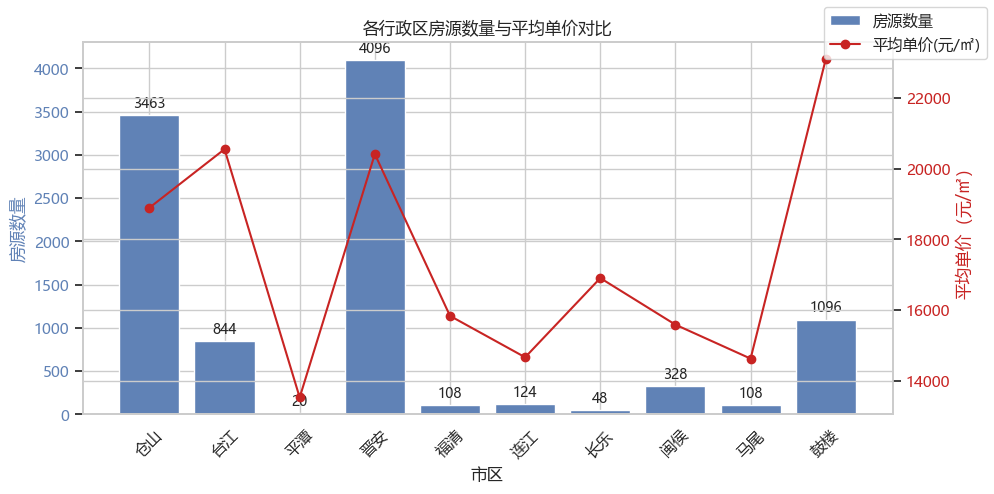

In [26]:
# 全局字体修复 + 屏蔽警告，解决方框乱码和日志刷屏
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10,5))
# 1. 分组统计数据
count_data = df_clean.groupby("市区")["id"].count()
price_data = df_clean.groupby("市区")["clean_avg"].mean()

# 左轴：柱状图 房源数量
bars = ax1.bar(count_data.index, count_data.values, color="#6082B6", label="房源数量")
ax1.set_xlabel("市区")
ax1.set_ylabel("房源数量", color="#6082B6")
ax1.tick_params(axis="y", labelcolor="#6082B6")
plt.xticks(rotation=45)

# 在每个柱子上方标注房源数字
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 40,
             f"{int(h)}", ha="center", va="bottom", fontsize=10)

# 右轴：折线图 平均单价
ax2 = ax1.twinx()
line = ax2.plot(price_data.index, price_data.values, color="#c82423", marker="o", label="平均单价(元/㎡)")
ax2.set_ylabel("平均单价（元/㎡）", color="#c82423")
ax2.tick_params(axis="y", labelcolor="#c82423")

plt.title("各行政区房源数量与平均单价对比")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 图表1：福州各行政区二手房房源数量对比
柱状图统计各行政区挂牌房源总量，直观反映区域二手房供给规模。
由图可见：晋安区房源数量最高，市场供给最充足；鼓楼、仓山次之；其余片区挂牌房源偏少，二手房流通量较低。

### 图表2：分行政区、楼层二手房单价箱线图


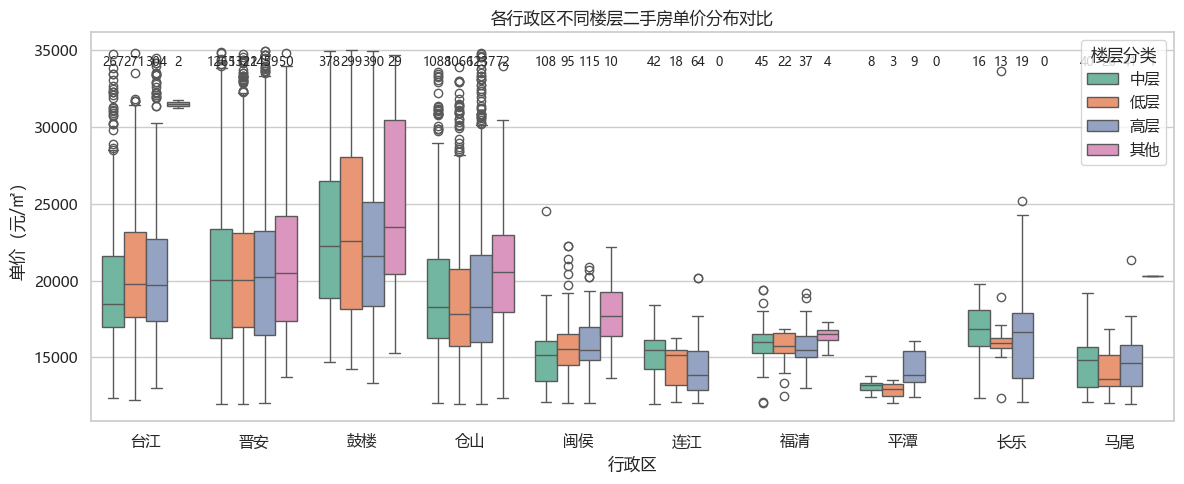

In [27]:
# import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,5))
ax = sns.boxplot(data=df_clean, x="市区", y="clean_avg", hue="楼层分类", palette="Set2")

# 在每组箱体上方标注该组房源总数
from collections import defaultdict
group_count = defaultdict(int)
for _, row in df_clean.iterrows():
    group = (row["市区"], row["楼层分类"])
    group_count[group] += 1

# 获取x轴标签位置、图例分类
x_labels = [tick.get_text() for tick in ax.get_xticklabels()]
hue_cats = df_clean["楼层分类"].unique()
width = 0.8 / len(hue_cats)

for i, area in enumerate(x_labels):
    for j, floor in enumerate(hue_cats):
        cnt = group_count[(area, floor)]
        pos = i - 0.4 + width/2 + j*width
        ax.text(pos, df_clean["clean_avg"].max()*0.97, f"{cnt}", ha="center", fontsize=9)

plt.title("各行政区不同楼层二手房单价分布对比")
plt.xlabel("行政区")
plt.ylabel("单价（元/㎡）")
plt.legend(title="楼层分类")
plt.tight_layout()
plt.show()


### 图表2：分行政区、楼层二手房单价箱线图
以行政区为横轴、楼层为分组，箱线展示各组房价中位数、四分位数与异常高价房源；每组上方标注对应房源数量，同时结合地段、楼层两个维度分析房价：
1. 价格规律统一：全部行政区内，中层房源均价＞高层＞低层，中层房源市场认可度最高；
2. 地段溢价显著：相同楼层条件下，鼓楼区房价整体远高于仓山、台江、晋安，地段对房价影响大于楼层；
3. 流通规模：中层房源每组标注数量普遍更多，市场流通性更强；低层房源挂牌量偏少，整体购房预算门槛最低。

### 图表 3：各行政区房源面积分布

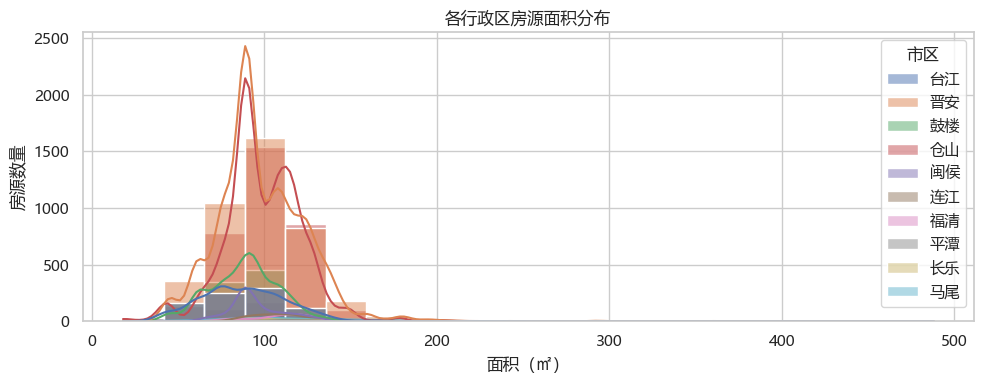

In [28]:
# 在这里绘制第 3 张图
# 按市区分组的面积直方图
plt.figure(figsize=(10,4))
sns.histplot(data=df_clean, x="clean_area", hue="市区", bins=20, kde=True)
plt.title("各行政区房源面积分布")
plt.xlabel("面积（㎡）")
plt.ylabel("房源数量")
plt.tight_layout()
plt.show()

### 图表3：各行政区房源面积分布
按行政区分组展示面积分布，对比片区户型差异：
1. 鼓楼区大面积房源占比更高，改善型户型更多；
2. 仓山、台江小户型占比更高，刚需小户型供给充足；
3. 晋安区面积分布最均衡，大、小户型均有充足挂牌。

### 图表 4：各行政区房源多维指标堆叠面积对比图

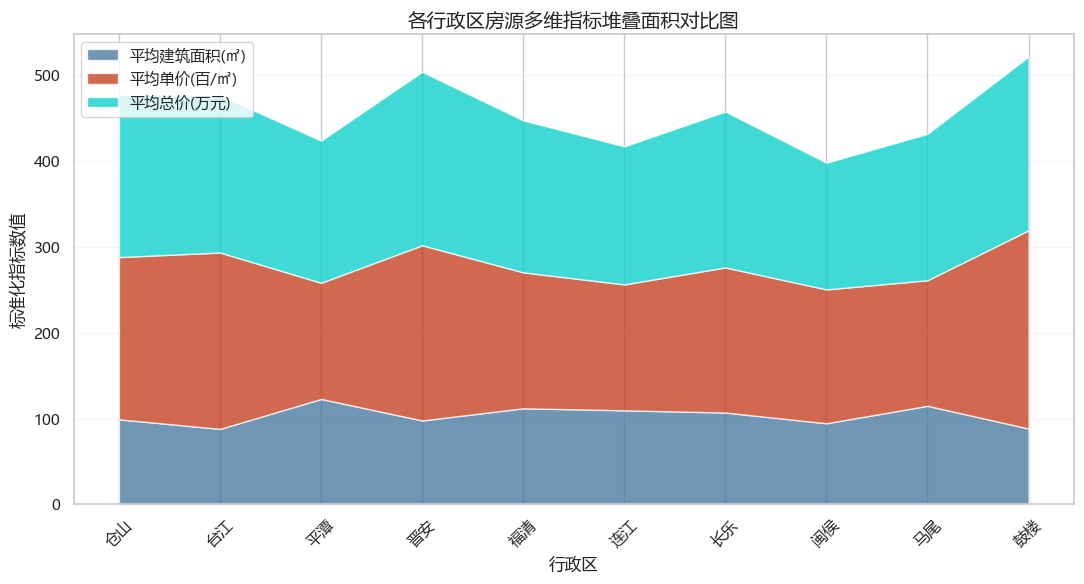

In [29]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 中文防方框乱码
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 先聚合，不在agg内做计算
group_df = df_clean.groupby("市区").agg(
    平均面积=("clean_area", "mean"),
    平均单价=("clean_avg", "mean"),
    平均总价=("clean_total", "mean")
).reset_index()

# 2. 聚合完成后再缩放单价数值
group_df["平均单价"] = group_df["平均单价"] / 100

# 绘图
plt.figure(figsize=(11,6))
x = group_df["市区"]
y1 = group_df["平均面积"]
y2 = group_df["平均单价"]
y3 = group_df["平均总价"]

plt.stackplot(x, y1, y2, y3, 
              labels=["平均建筑面积(㎡)","平均单价(百/㎡)","平均总价(万元)"],
              colors=["#40739e","#c23616","#00cec9"], alpha=0.75)

# 美化设置
plt.title("各行政区房源多维指标堆叠面积对比图", fontsize=14)
plt.xlabel("行政区")
plt.ylabel("标准化指标数值")
plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 图表4：各行政区房源多维指标堆叠面积对比图
堆叠面积图分层展示各区平均建筑面积、折算后平均单价、平均总价三层指标，色块分层直观对比片区房产综合水平，无密集数据点。
1. 鼓楼区整体色块总高度最高，三项指标同步领先，大面积、高单价改善房源集中；
2. 仓山区、台江区色块整体偏低，小户型、低总价刚需房源为市场主力；
3. 晋安区三层指标分布均衡，总色块面积最大，挂牌房源供给充足，刚需与改善需求均可覆盖；
4. 综合结论：地段资源同步拉高户型面积、单位均价与房屋总价，二手房市场按行政区形成清晰价格分层。

## 8. 主要结论

### 8.1四项核心分析发现
1. **各行政区线上二手房挂牌供给规模差距明显，晋安区为全市房源供给主力**
本次数据清洗仅剔除缺失值与重复房源，剩余有效样本按行政区分组统计可见晋安区挂牌房源数量最多；图表1房源数量与均价双轴图直观体现，晋安区房源总量显著高于其余片区，鼓楼区供给量次之，仓山、台江等区域挂牌体量偏少，线上二手房挂牌供给集中于晋安区。

2. **地段是影响房价的首要因素，鼓楼区存在显著地段溢价，片区市场定位分层清晰**
分组描述统计显示鼓楼区单价、总价均值与四分位数均高于其他行政区；图表1均价折线、图表2行政区+楼层分组箱线图、图表4多维指标堆叠面积图均可佐证：同等面积、同等楼层条件下，鼓楼房源价格全面领先，仓山、台江房价整体偏低，晋安区各项指标居中；地段带来的价差幅度明显超过楼层带来的价格差异。

3. **全市二手房户型呈单峰集中分布，80–110㎡中小刚需户型是市场流通核心**
面积字段描述统计均值、四分位数反映样本集中在中小面积区间；图表3房源面积分布直方图进一步可视化分布特征，房源数量峰值落在80~110㎡区间，60㎡以下小户型、140㎡以上大户型挂牌量大幅缩减，大面积改善型房源线上挂牌稀缺，刚需住宅占据市场主流。

4. **全部行政区遵循统一楼层价格梯度：中层房源均价＞高层＞低层，且中层房源流通性更强**
按行政区、楼层交叉分组统计显示中层房源均价均值最高；图表2双层分组箱线图验证该规律，所有片区内中层箱体位置整体更高，低层房价下限最低；同时各组标注样本数量显示中层挂牌房源更多，市场流通表现优于高层、低层房源。

### 8.2结论对应支撑材料（清洗统计+可视化图表）
1. 片区供给规模差异：缺失/重复值清洗后样本计数、分组描述统计、图表1房源数量与均价双轴对比图；
2. 地段房价溢价分层：多维度分组描述统计、图表1均价折线、图表2分层箱线图、图表4多维指标堆叠面积图；
3. 刚需户型集中分布：面积字段描述统计、图表3房源面积分布直方图；
4. 楼层固定价格梯度：行政区-楼层交叉分组统计、图表2双层分组箱线图。

### 8.3数据局限性与结论谨慎说明
1. 样本仅来源于线上房产挂牌平台，不含线下交易、历史成交数据，结论仅反映挂牌供给市场，不能完全等同于真实二手房成交市场。
2. 数据集缺少学区、房龄、地铁配套、装修等关键房价影响变量，无法剥离配套因素干扰，不能将片区房价差异完全归因于行政区地段。
3. 数据清洗仅删除缺失、重复样本，未过滤极端价格房源，数据内存在少量超高/超低单价极端样本，会轻微拉高或拉低片区均值，相关均价结论需谨慎解读。
4. 数据为单一时间截面静态数据，无时间序列信息，无法分析政策、季节带来的房价与挂牌量波动，结论仅代表数据采集当期市场状态。